In [1]:
include(joinpath(dirname(pwd()), "src", "VoterResetting.jl"))
using .VoterResetting
using Plots
using Base.Threads
using Printf

N = 1000
r_values = LinRange(0, 20, 41)
m0_values = LinRange(0, 1-1/N, 20)
nsamples = 10000  # Was 40000; use this for iterative runs
M_theory = 15_000
total = length(m0_values) * length(r_values)

fig_dir = joinpath(dirname(pwd()), "figures", "all_to_all")
mkpath(fig_dir)

function min_location_type(j::Int, n::Int)
    if j == 1
        return "lower-bound"
    elseif j == n
        return "upper-bound"
    else
        return "interior"
    end
end

println(nthreads())

8


# Simulation

In [2]:
function mean_fpt_fast(N::Int, m0::Float64, r_mc::Float64, nsamples::Int)
    r_ct = r_mc / N
    reset_protocol = VoterResetting.delta_reset(m0)
    # threadid() can be larger than nthreads() when multiple thread pools are active.
    partial_sums = zeros(Float64, Threads.maxthreadid())

    # Dynamic scheduling helps because trajectory lengths are highly variable.
    Threads.@threads :dynamic for k in 1:nsamples
        tid = Threads.threadid()
        partial_sums[tid] += VoterResetting.simulate_fpt_all_to_all_trajectory(
            N,
            m0,
            r_ct,
            reset_protocol,
            :either,
        )
    end

    return sum(partial_sums) / nsamples
end

function min_location_type(j::Int, n::Int)
    if j == 1
        return "lower-bound"
    elseif j == n
        return "upper-bound"
    else
        return "interior"
    end
end


min_location_type (generic function with 1 method)

In [4]:
using Printf
t0 = time()
val = mean_fpt_fast(N, 0.5, 2.0, 10000)
@printf("single call done in %.2fs, mfpt=%.6g\n", time()-t0, val)

single call done in 11.15s, mfpt=638.163


[SIM 1/820] m0=0.0000 r=0.0000 | cell=9.19s | elapsed=9.2s | eta=7548.7s
[SIM 2/820] m0=0.0000 r=0.5000 | cell=10.69s | elapsed=20.1s | eta=8238.1s
[SIM 3/820] m0=0.0000 r=1.0000 | cell=17.26s | elapsed=37.4s | eta=10185.8s
[SIM 4/820] m0=0.0000 r=1.5000 | cell=22.02s | elapsed=59.4s | eta=12123.1s
[SIM 5/820] m0=0.0000 r=2.0000 | cell=21.84s | elapsed=81.3s | eta=13246.8s
[SIM 6/820] m0=0.0000 r=2.5000 | cell=25.68s | elapsed=107.0s | eta=14509.7s
[SIM 7/820] m0=0.0000 r=3.0000 | cell=26.65s | elapsed=133.6s | eta=15516.6s
[SIM 8/820] m0=0.0000 r=3.5000 | cell=29.72s | elapsed=163.3s | eta=16576.6s
[SIM 9/820] m0=0.0000 r=4.0000 | cell=31.96s | elapsed=195.3s | eta=17596.5s
[SIM 10/820] m0=0.0000 r=4.5000 | cell=34.41s | elapsed=229.7s | eta=18604.6s
[SIM 11/820] m0=0.0000 r=5.0000 | cell=37.55s | elapsed=267.2s | eta=19654.1s
[SIM 12/820] m0=0.0000 r=5.5000 | cell=52.36s | elapsed=319.6s | eta=21519.7s
[SIM 13/820] m0=0.0000 r=6.0000 | cell=60.67s | elapsed=380.3s | eta=23606.1s
[SIM

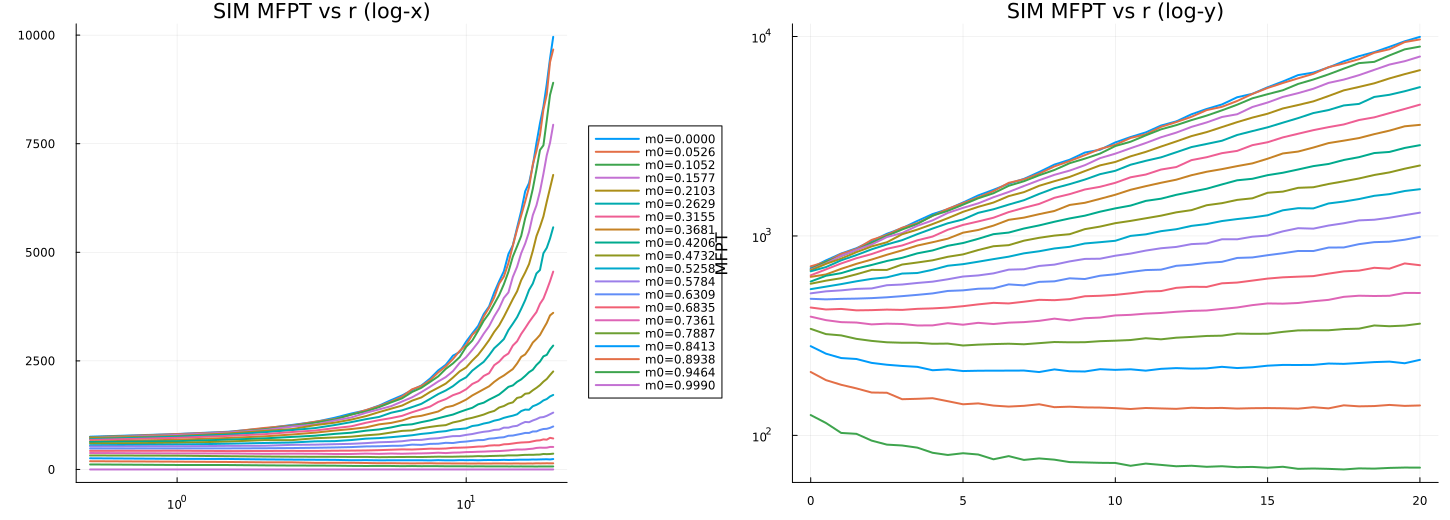

Saved simulation MFPT figure: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\figures\all_to_all\mfpt_vs_r_logx_logy_2.png
SIM m0=0.0000 -> r*=0.0000, MFPT_min=690.3725 [lower-bound]
SIM m0=0.0526 -> r*=0.0000, MFPT_min=704.1564 [lower-bound]
SIM m0=0.1052 -> r*=0.0000, MFPT_min=681.5459 [lower-bound]
SIM m0=0.1577 -> r*=0.0000, MFPT_min=676.7967 [lower-bound]
SIM m0=0.2103 -> r*=0.0000, MFPT_min=672.2598 [lower-bound]
SIM m0=0.2629 -> r*=0.0000, MFPT_min=664.9418 [lower-bound]
SIM m0=0.3155 -> r*=0.0000, MFPT_min=634.8781 [lower-bound]
SIM m0=0.3681 -> r*=0.0000, MFPT_min=623.5593 [lower-bound]
SIM m0=0.4206 -> r*=0.0000, MFPT_min=590.8547 [lower-bound]
SIM m0=0.4732 -> r*=0.0000, MFPT_min=576.0018 [lower-bound]
SIM m0=0.5258 -> r*=0.0000, MFPT_min=541.0793 [lower-bound]
SIM m0=0.5784 -> r*=0.0000, MFPT_min=515.4920 [lower-bound]
SIM m0=0.6309 -> r*=0.5000, MFPT_min=480.8602 [interior]
SIM m0=0.6835 -> r*=1.5000, MFPT_min=423.6009 [interior]
SIM m

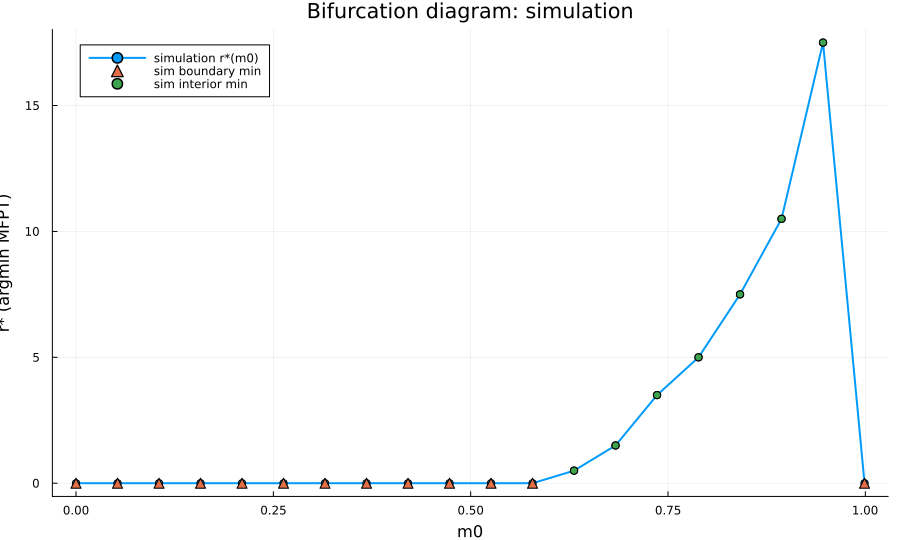

Saved simulation bifurcation diagram: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\figures\all_to_all\bifurcation_rstar_vs_m0_sim.png


In [5]:
# --- Simulation branch: MFPT(r,m0), min classification, and bifurcation diagram ---
mfpt = zeros(length(m0_values), length(r_values))
start_time = time()
done = 0
total = length(m0_values) * length(r_values)

for (i, m0) in enumerate(m0_values)
    for (j, r) in enumerate(r_values)
        t_cell = time()
        mfpt[i, j] = mean_fpt_fast(N, m0, r, nsamples)
        done += 1

        elapsed = time() - start_time
        rate = done / max(elapsed, 1e-9)
        eta = (total - done) / max(rate, 1e-9)

        @printf("[SIM %d/%d] m0=%.4f r=%.4f | cell=%.2fs | elapsed=%.1fs | eta=%.1fs\n",
            done, total, m0, r, time()-t_cell, elapsed, eta)
        flush(stdout)
    end
end

labels = reshape([@sprintf("m0=%.4f", m0) for m0 in m0_values], 1, :)

# For log-x, skip r=0 because log scale is undefined there.
r_pos = r_values[2:end]
mfpt_posx = mfpt[:, 2:end]

# For log-y, protect against any non-positive numerical artifacts.
mfpt_posy = copy(mfpt)
mfpt_posy[mfpt_posy .<= 0] .= NaN

p_logx = plot(
    r_pos,
    mfpt_posx';
    xlabel = "r",
    ylabel = "MFPT",
    title = "SIM MFPT vs r (log-x)",
    xscale = :log10,
    label = labels,
    legend = :outerright,
    linewidth = 2,
    size = (700, 450),
)

p_logy = plot(
    r_values,
    mfpt_posy';
    xlabel = "r",
    ylabel = "MFPT",
    title = "SIM MFPT vs r (log-y)",
    yscale = :log10,
    label = labels,
    legend = false,
    linewidth = 2,
    size = (700, 450),
)

p_both = plot(p_logx, p_logy; layout = (1, 2), size = (1450, 520))
display(p_both)

fig_path = joinpath(fig_dir, "mfpt_vs_r_logx_logy_2.png")
savefig(p_both, fig_path)
println("Saved simulation MFPT figure: ", fig_path)

# --- Bifurcation from simulation: classify minima as interior or boundary ---
r_star_sim = zeros(length(m0_values))
mfpt_min_sim = zeros(length(m0_values))
is_boundary_sim = falses(length(m0_values))
min_type_sim = Vector{String}(undef, length(m0_values))

for i in eachindex(m0_values)
    row = mfpt[i, :]
    j_star = argmin(row)
    r_star_sim[i] = r_values[j_star]
    mfpt_min_sim[i] = row[j_star]
    min_type_sim[i] = min_location_type(j_star, length(r_values))
    is_boundary_sim[i] = (min_type_sim[i] != "interior")
    @printf("SIM m0=%.4f -> r*=%.4f, MFPT_min=%.4f [%s]\n", m0_values[i], r_star_sim[i], mfpt_min_sim[i], min_type_sim[i])
end

n_sim_boundary = count(is_boundary_sim)
println("Simulation minima: interior=$(length(m0_values)-n_sim_boundary), boundary=$n_sim_boundary")

sim_leave_idx = findfirst(t -> t != "lower-bound", min_type_sim)
if sim_leave_idx !== nothing
    @printf("SIM first leaves r=0 at m0=%.4f (r*=%.4f)\n", m0_values[sim_leave_idx], r_star_sim[sim_leave_idx])
else
    println("SIM: minimum stays at r=0 for all scanned m0.")
end

# --- Bifurcation diagram (simulation only) ---
p_bif_sim = plot(
    m0_values,
    r_star_sim;
    seriestype = :path,
    marker = :circle,
    linewidth = 2,
    xlabel = "m0",
    ylabel = "r* (argmin MFPT)",
    title = "Bifurcation diagram: simulation",
    label = "simulation r*(m0)",
    size = (900, 540),
)

idx_sim_boundary = findall(is_boundary_sim)
idx_sim_interior = findall(.!is_boundary_sim)
if !isempty(idx_sim_boundary)
    scatter!(p_bif_sim, m0_values[idx_sim_boundary], r_star_sim[idx_sim_boundary];
        marker=:utriangle, ms=5, label="sim boundary min")
end
if !isempty(idx_sim_interior)
    scatter!(p_bif_sim, m0_values[idx_sim_interior], r_star_sim[idx_sim_interior];
        marker=:circle, ms=4, label="sim interior min")
end

display(p_bif_sim)

bif_sim_path = joinpath(fig_dir, "bifurcation_rstar_vs_m0_sim.png")
savefig(p_bif_sim, bif_sim_path)
println("Saved simulation bifurcation diagram: ", bif_sim_path)

# Theory

[THEORY row 1/50] m0=0.0000 done
[THEORY row 2/50] m0=0.0204 done
[THEORY row 3/50] m0=0.0408 done
[THEORY row 4/50] m0=0.0612 done
[THEORY row 5/50] m0=0.0816 done
[THEORY row 6/50] m0=0.1019 done
[THEORY row 7/50] m0=0.1223 done
[THEORY row 8/50] m0=0.1427 done
[THEORY row 9/50] m0=0.1631 done
[THEORY row 10/50] m0=0.1835 done
[THEORY row 11/50] m0=0.2039 done
[THEORY row 12/50] m0=0.2243 done
[THEORY row 13/50] m0=0.2447 done
[THEORY row 14/50] m0=0.2650 done
[THEORY row 15/50] m0=0.2854 done
[THEORY row 16/50] m0=0.3058 done
[THEORY row 17/50] m0=0.3262 done
[THEORY row 18/50] m0=0.3466 done
[THEORY row 19/50] m0=0.3670 done
[THEORY row 20/50] m0=0.3874 done
[THEORY row 21/50] m0=0.4078 done
[THEORY row 22/50] m0=0.4281 done
[THEORY row 23/50] m0=0.4485 done
[THEORY row 24/50] m0=0.4689 done
[THEORY row 25/50] m0=0.4893 done
[THEORY row 26/50] m0=0.5097 done
[THEORY row 27/50] m0=0.5301 done
[THEORY row 28/50] m0=0.5505 done
[THEORY row 29/50] m0=0.5709 done
[THEORY row 30/50] m0=0

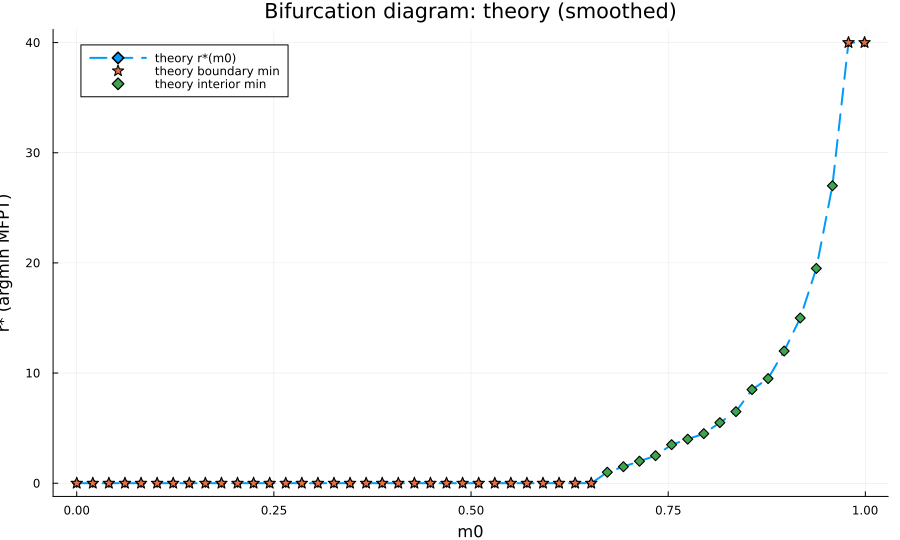

Saved theory bifurcation diagram: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\figures\all_to_all\bifurcation_rstar_vs_m0_theory_smoothed.png


In [2]:
using Statistics

# --- Theory branch: compute independently and build theory bifurcation diagram ---
mfpt_theory = zeros(length(m0_values), length(r_values))
for (i, m0) in enumerate(m0_values)
    for (j, r) in enumerate(r_values)
        mfpt_theory[i, j] = VoterResetting.mean_fpt(N, m0, r; M=M_theory)
    end
    @printf("[THEORY row %d/%d] m0=%.4f done\n", i, length(m0_values), m0)
end

# Smooth rare divergence spikes before extracting argmin.
function smooth_nan_median(v::Vector{Float64}; window::Int=5)
    w = max(window, 3)
    if iseven(w)
        w += 1
    end
    h = (w - 1) ÷ 2
    out = similar(v)
    n = length(v)
    for i in 1:n
        lo = max(1, i - h)
        hi = min(n, i + h)
        chunk = v[lo:hi]
        finite_chunk = chunk[isfinite.(chunk)]
        out[i] = isempty(finite_chunk) ? NaN : median(finite_chunk)
    end
    return out
end

mfpt_theory_clean = copy(mfpt_theory)
mfpt_theory_clean[.!isfinite.(mfpt_theory_clean)] .= NaN
mfpt_theory_clean[mfpt_theory_clean .<= 0] .= NaN

# Extra protection against huge divergence spikes: clip at row-wise 95th percentile.
for i in axes(mfpt_theory_clean, 1)
    row = collect(mfpt_theory_clean[i, :])
    finite_row = row[isfinite.(row)]
    if !isempty(finite_row)
        cap = quantile(finite_row, 0.95)
        for j in eachindex(row)
            if isfinite(row[j]) && row[j] > cap
                row[j] = cap
            end
        end
        mfpt_theory_clean[i, :] = row
    end
end

mfpt_theory_smooth = similar(mfpt_theory_clean)
for i in axes(mfpt_theory_clean, 1)
    mfpt_theory_smooth[i, :] = smooth_nan_median(collect(mfpt_theory_clean[i, :]); window=5)
end

r_star_theory = zeros(length(m0_values))
mfpt_min_theory = zeros(length(m0_values))
is_boundary_theory = falses(length(m0_values))
min_type_theory = Vector{String}(undef, length(m0_values))

for i in eachindex(m0_values)
    row = collect(mfpt_theory_smooth[i, :])
    valid = findall(isfinite, row)
    if isempty(valid)
        row_raw = collect(mfpt_theory[i, :])
        j_star = argmin(row_raw)
    else
        j_local = argmin(row[valid])
        j_star = valid[j_local]
    end

    r_star_theory[i] = r_values[j_star]
    mfpt_min_theory[i] = row[j_star]
    min_type_theory[i] = min_location_type(j_star, length(r_values))
    is_boundary_theory[i] = (min_type_theory[i] != "interior")
    @printf("THEORY m0=%.4f -> r*=%.4f, MFPT_min=%.4f [%s]\n", m0_values[i], r_star_theory[i], mfpt_min_theory[i], min_type_theory[i])
end

n_theory_boundary = count(is_boundary_theory)
println("Theory minima: interior=$(length(m0_values)-n_theory_boundary), boundary=$n_theory_boundary")

theory_leave_idx = findfirst(t -> t != "lower-bound", min_type_theory)
if theory_leave_idx !== nothing
    @printf("THEORY first leaves r=0 at m0=%.4f (r*=%.4f)\n", m0_values[theory_leave_idx], r_star_theory[theory_leave_idx])
else
    println("THEORY: minimum stays at r=0 for all scanned m0.")
end

p_bif_theory = plot(
    m0_values,
    r_star_theory;
    seriestype = :path,
    marker = :diamond,
    linewidth = 2,
    ls = :dash,
    xlabel = "m0",
    ylabel = "r* (argmin MFPT)",
    title = "Bifurcation diagram: theory (smoothed)",
    label = "theory r*(m0)",
    size = (900, 540),
)

idx_theory_boundary = findall(is_boundary_theory)
idx_theory_interior = findall(.!is_boundary_theory)
if !isempty(idx_theory_boundary)
    scatter!(p_bif_theory, m0_values[idx_theory_boundary], r_star_theory[idx_theory_boundary];
        marker=:star5, ms=6, label="theory boundary min")
end
if !isempty(idx_theory_interior)
    scatter!(p_bif_theory, m0_values[idx_theory_interior], r_star_theory[idx_theory_interior];
        marker=:diamond, ms=5, label="theory interior min")
end

display(p_bif_theory)

bif_theory_path = joinpath(fig_dir, "bifurcation_rstar_vs_m0_theory_smoothed.png")
savefig(p_bif_theory, bif_theory_path)
println("Saved theory bifurcation diagram: ", bif_theory_path)